# Limit Order Book — Exploratory Data Analysis (BTCIRT / USDTIRT)

This notebook loads the raw 20-level order book snapshots and trade tapes from
`../data/` for **BTCIRT** and **USDTIRT** and explores their structure ahead of
training a DeepLOB model.

1. [Data Loading & Schema](#1.-Data-Loading-&-Schema)
2. [Coverage & Sampling Frequency](#2.-Coverage-&-Sampling-Frequency)
3. [Missing Data Analysis](#3.-Missing-Data-Analysis)
4. [LOB Snapshot Visualization](#4.-LOB-Snapshot-Visualization)
5. [Mid-Price & Spread](#5.-Mid-Price-&-Spread)
6. [Order Imbalance](#6.-Order-Imbalance)
7. [Price Level Spacing (Tick Structure)](#7.-Price-Level-Spacing)
8. [Trades Analysis](#8.-Trades-Analysis)
9. [Forward Returns & Alpha Exploration](#9.-Forward-Returns-&-Alpha-Exploration)
10. [Cross-Asset Summary](#10.-Cross-Asset-Summary)


In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

# ── configuration ────────────────────────────────────────────────────────────
DATA_DIR = "../data"
ASSETS = ["BTCIRT", "USDTIRT"]
ASSET_COLORS = {"BTCIRT": "steelblue", "USDTIRT": "darkorange"}
N_LEVELS = 20

ASK_PRICE_COLS = [f"ask_price_{i}" for i in range(1, N_LEVELS + 1)]
BID_PRICE_COLS = [f"bid_price_{i}" for i in range(1, N_LEVELS + 1)]
ASK_VOL_COLS = [f"ask_volume_{i}" for i in range(1, N_LEVELS + 1)]
BID_VOL_COLS = [f"bid_volume_{i}" for i in range(1, N_LEVELS + 1)]
ALL_PRICE_COLS = ASK_PRICE_COLS + BID_PRICE_COLS
ALL_VOL_COLS = ASK_VOL_COLS + BID_VOL_COLS
LEVELS = np.arange(1, N_LEVELS + 1)


---
## 1. Data Loading & Schema

In [2]:
ob, tr = {}, {}
for sym in ASSETS:
    df = pd.read_csv(f"{DATA_DIR}/{sym}_orderbook.csv")
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    ob[sym] = df

    t = pd.read_csv(f"{DATA_DIR}/{sym}_trades.csv")
    t["snapshot_time"] = pd.to_datetime(t["snapshot_time"])
    t["trade_time"] = pd.to_datetime(t["trade_time"])
    t = t.sort_values("trade_time").reset_index(drop=True)
    tr[sym] = t

for sym in ASSETS:
    print(f"{sym:8s}  orderbook {ob[sym].shape}   trades {tr[sym].shape}")


BTCIRT    orderbook (17348, 81)   trades (16527, 5)
USDTIRT   orderbook (17483, 81)   trades (60492, 5)


In [3]:
print("── BTCIRT orderbook — columns & dtypes (first 10) ──")
print(ob["BTCIRT"].dtypes.head(10).to_string())
print()
print("── BTCIRT trades — columns & dtypes ──")
print(tr["BTCIRT"].dtypes.to_string())


── BTCIRT orderbook — columns & dtypes (first 10) ──
time            datetime64[ns]
bid_price_1              int64
bid_volume_1           float64
ask_price_1              int64
ask_volume_1           float64
bid_price_2              int64
bid_volume_2           float64
ask_price_2              int64
ask_volume_2           float64
bid_price_3              int64

── BTCIRT trades — columns & dtypes ──
snapshot_time    datetime64[ns]
trade_time       datetime64[ns]
price                     int64
volume                  float64
direction                object


In [4]:
print("Orderbook — first 3 rows (L1-L3 only)")
preview_cols = ["time"] + [f"{side}_{kind}_{i}" for i in (1, 2, 3) for side, kind in [("bid", "price"), ("bid", "volume"), ("ask", "price"), ("ask", "volume")]]
ob["BTCIRT"][[c for c in preview_cols if c in ob["BTCIRT"].columns]].head(3)


Orderbook — first 3 rows (L1-L3 only)


,time,bid_price_1,bid_volume_1,ask_price_1,ask_volume_1,bid_price_2,bid_volume_2,ask_price_2,ask_volume_2,bid_price_3,bid_volume_3,ask_price_3,ask_volume_3
0,2026-06-05 18:03:38,106230000010,0.000430,106554481440,0.000880,106230000000,0.001942,106554481450,0.006571,106220000130,0.000076,106554481480,0.011877
1,2026-06-05 18:03:48,106230000000,0.001942,106230000010,0.010868,106220000130,0.000076,106554481400,0.000880,106220000060,0.000114,106554481430,0.001063
2,2026-06-05 18:03:58,106230000000,0.001942,106230000010,0.003338,106220000060,0.000114,106554481400,0.000880,106220000030,0.000114,106554481440,0.002815


In [5]:
print("Trades — first 5 rows")
tr["BTCIRT"].head(5)


Trades — first 5 rows


,snapshot_time,trade_time,price,volume,direction
0,2026-06-05 18:03:38,2026-06-05 17:59:39.803,106209910350,0.000001,sell
1,2026-06-05 18:03:38,2026-06-05 17:59:42.842,106209960360,0.000431,buy
2,2026-06-05 18:03:38,2026-06-05 17:59:51.102,106620842060,0.000006,buy
3,2026-06-05 18:03:38,2026-06-05 18:00:26.991,106210000010,0.000880,sell
4,2026-06-05 18:03:38,2026-06-05 18:00:28.776,106210000010,0.000704,buy


In [6]:
for sym in ASSETS:
    print(f"── {sym} L1 describe ──")
    print(ob[sym][["bid_price_1", "ask_price_1", "bid_volume_1", "ask_volume_1"]].describe().T)
    print()


── BTCIRT L1 describe ──
                count          mean           std           min           25%  \
bid_price_1   17348.0  1.076704e+11  1.855754e+09  1.033122e+11  1.062864e+11   
ask_price_1   17348.0  1.078630e+11  1.803422e+09  1.034400e+11  1.065000e+11   
bid_volume_1  17348.0  6.469320e-03  1.376174e-02  1.000000e-06  4.420000e-04   
ask_volume_1  17348.0  4.686545e-03  1.079188e-02  1.000000e-06  6.710000e-04   

                       50%           75%           max  
bid_price_1   1.070000e+11  1.092000e+11  1.115000e+11  
ask_price_1   1.072200e+11  1.093064e+11  1.116339e+11  
bid_volume_1  1.650500e-03  6.445250e-03  2.457730e-01  
ask_volume_1  1.301000e-03  5.518250e-03  1.790880e-01  

── USDTIRT L1 describe ──
                count          mean           std         min          25%  \
bid_price_1   17483.0  1.754940e+06  12982.736401  1740660.00  1746920.000   
ask_price_1   17483.0  1.755704e+06  12851.199069  1740680.00  1747900.000   
bid_volume_1  17483.0  

---
## 2. Coverage & Sampling Frequency

In [7]:
for sym in ASSETS:
    df = ob[sym]
    diffs = df["time"].diff().dt.total_seconds().dropna()
    print(f"── {sym} ──")
    print(f"  range        : {df['time'].min()}  →  {df['time'].max()}")
    print(f"  n snapshots  : {len(df):,}")
    print(f"  median Δt    : {diffs.median():.1f}s   mean Δt: {diffs.mean():.2f}s")
    print(f"  max gap      : {diffs.max():.0f}s")
    print(f"  gaps > 30s   : {(diffs > 30).sum()}")
    print()


── BTCIRT ──
  range        : 2026-06-05 18:03:38  →  2026-06-07 20:18:38
  n snapshots  : 17,348
  median Δt    : 10.0s   mean Δt: 10.43s
  max gap      : 65s
  gaps > 30s   : 162

── USDTIRT ──
  range        : 2026-06-05 18:03:38  →  2026-06-07 20:18:28
  n snapshots  : 17,483
  median Δt    : 10.0s   mean Δt: 10.35s
  max gap      : 68s
  gaps > 30s   : 137



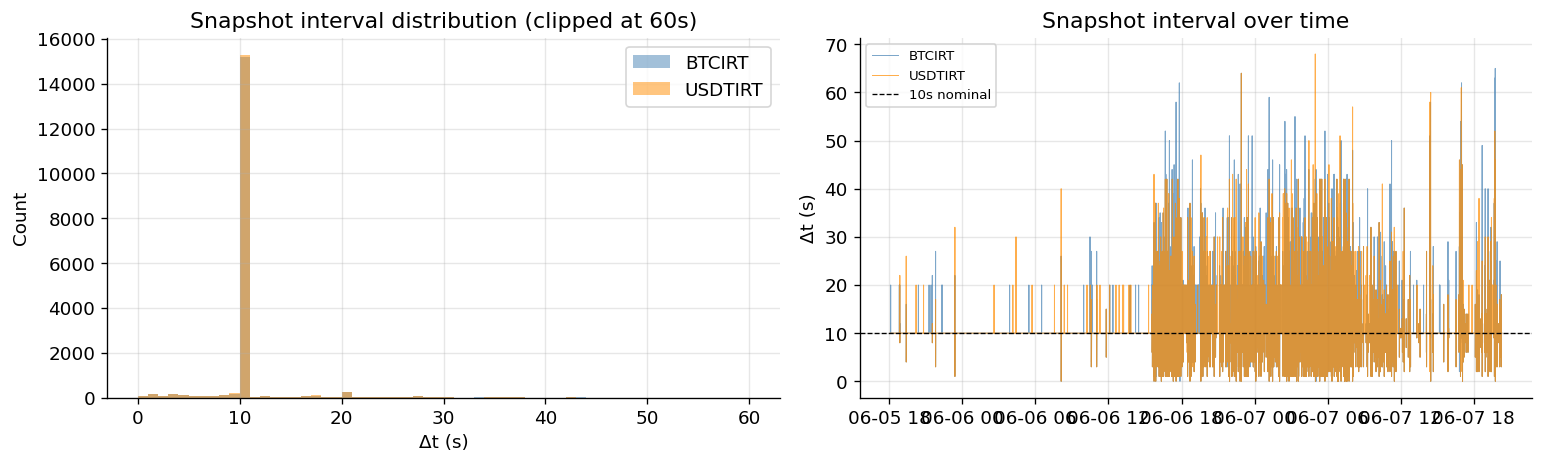

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sym in ASSETS:
    diffs = ob[sym]["time"].diff().dt.total_seconds().dropna()
    axes[0].hist(diffs.clip(upper=60), bins=60, alpha=0.5, label=sym, color=ASSET_COLORS[sym])
axes[0].set_title("Snapshot interval distribution (clipped at 60s)")
axes[0].set_xlabel("Δt (s)")
axes[0].set_ylabel("Count")
axes[0].legend()

for sym in ASSETS:
    df = ob[sym]
    diffs = df["time"].diff().dt.total_seconds()
    axes[1].plot(df["time"], diffs, lw=0.6, alpha=0.7, label=sym, color=ASSET_COLORS[sym])
axes[1].axhline(10, color="black", lw=0.8, ls="--", label="10s nominal")
axes[1].set_title("Snapshot interval over time")
axes[1].set_ylabel("Δt (s)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 3. Missing Data Analysis

Unlike a sparse multi-asset panel, a single liquid pair's order book is expected to be (near) fully populated even at deep levels.

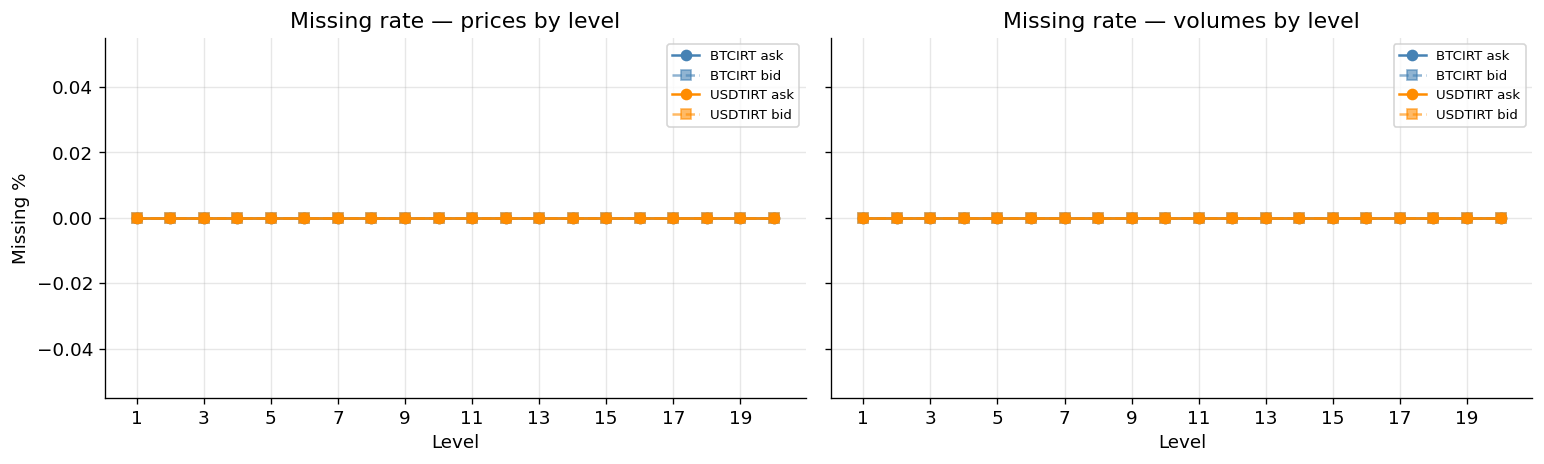

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for sym in ASSETS:
    null_price = ob[sym][ALL_PRICE_COLS].isnull().mean() * 100
    axes[0].plot(LEVELS, null_price[ASK_PRICE_COLS].values, "o-", label=f"{sym} ask", color=ASSET_COLORS[sym])
    axes[0].plot(LEVELS, null_price[BID_PRICE_COLS].values, "s--", label=f"{sym} bid", color=ASSET_COLORS[sym], alpha=0.6)
axes[0].set_title("Missing rate — prices by level")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Missing %")
axes[0].set_xticks(LEVELS[::2])
axes[0].legend(fontsize=8)

for sym in ASSETS:
    null_vol = ob[sym][ALL_VOL_COLS].isnull().mean() * 100
    axes[1].plot(LEVELS, null_vol[ASK_VOL_COLS].values, "o-", label=f"{sym} ask", color=ASSET_COLORS[sym])
    axes[1].plot(LEVELS, null_vol[BID_VOL_COLS].values, "s--", label=f"{sym} bid", color=ASSET_COLORS[sym], alpha=0.6)
axes[1].set_title("Missing rate — volumes by level")
axes[1].set_xlabel("Level")
axes[1].set_xticks(LEVELS[::2])
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 4. LOB Snapshot Visualization

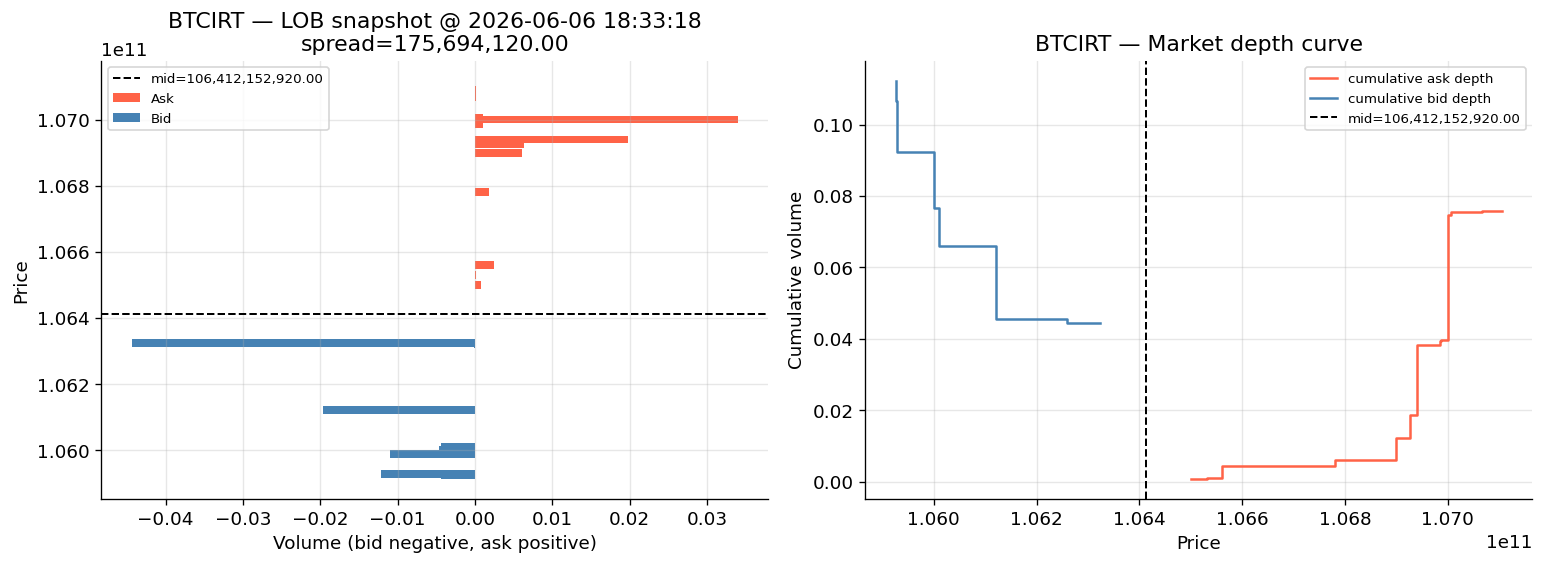

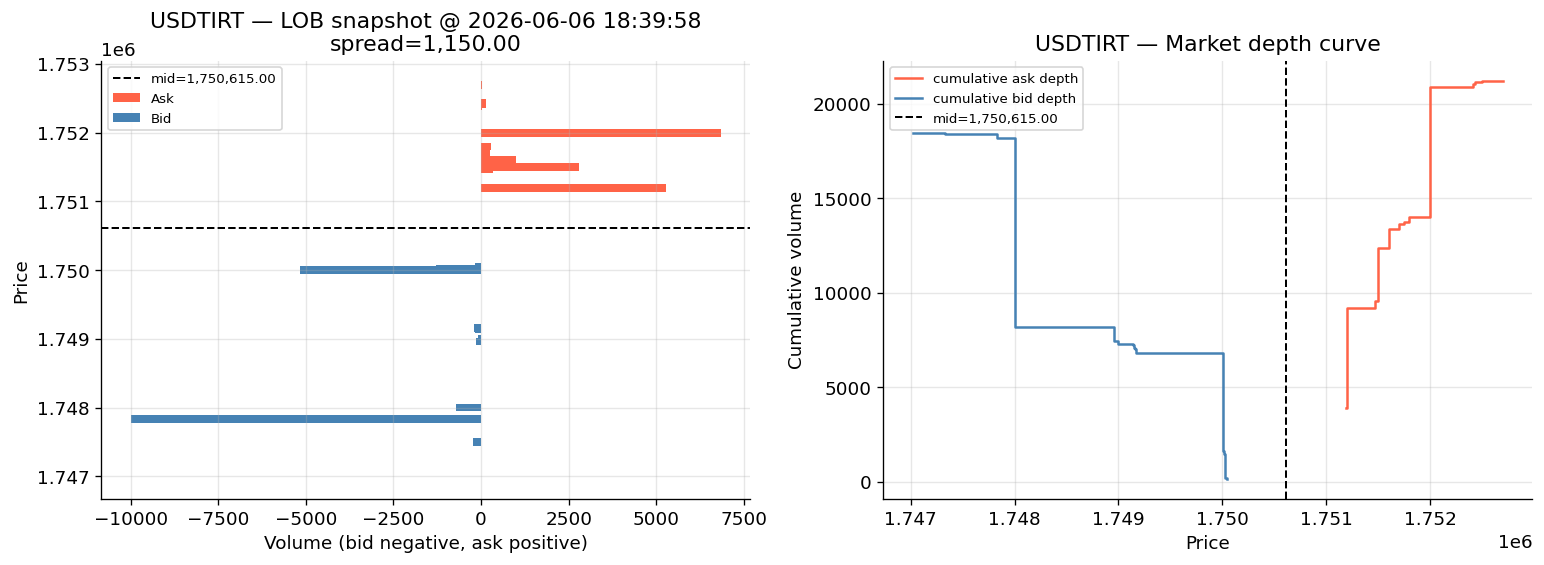

In [10]:
def plot_snapshot(sym, idx=None):
    df = ob[sym]
    if idx is None:
        idx = len(df) // 2
    snap = df.iloc[idx]

    ask_p = snap[ASK_PRICE_COLS].values.astype(float)
    bid_p = snap[BID_PRICE_COLS].values.astype(float)
    ask_v = snap[ASK_VOL_COLS].values.astype(float)
    bid_v = snap[BID_VOL_COLS].values.astype(float)

    mid = (ask_p[0] + bid_p[0]) / 2
    spread = ask_p[0] - bid_p[0]
    price_range = max(ask_p.max(), bid_p.max()) - min(ask_p.min(), bid_p.min())
    height = price_range * 0.02 if price_range > 0 else 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].barh(ask_p, ask_v, height=height, color="tomato", label="Ask", align="center")
    axes[0].barh(bid_p, -bid_v, height=height, color="steelblue", label="Bid", align="center")
    axes[0].axhline(mid, color="black", lw=1.2, ls="--", label=f"mid={mid:,.2f}")
    axes[0].set_title(f"{sym} — LOB snapshot @ {snap['time']}\nspread={spread:,.2f}")
    axes[0].set_xlabel("Volume (bid negative, ask positive)")
    axes[0].set_ylabel("Price")
    axes[0].legend(fontsize=8)

    cum_ask = np.nancumsum(ask_v)
    cum_bid = np.nancumsum(bid_v)
    axes[1].step(ask_p, cum_ask, where="post", color="tomato", label="cumulative ask depth")
    axes[1].step(bid_p[::-1], cum_bid[::-1], where="post", color="steelblue", label="cumulative bid depth")
    axes[1].axvline(mid, color="black", lw=1.2, ls="--", label=f"mid={mid:,.2f}")
    axes[1].set_title(f"{sym} — Market depth curve")
    axes[1].set_xlabel("Price")
    axes[1].set_ylabel("Cumulative volume")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


for sym in ASSETS:
    plot_snapshot(sym)


---
## 5. Mid-Price & Spread

The mid-price is the reference price for DeepLOB labels; the spread is the primary measure of execution cost.

In [11]:
for sym in ASSETS:
    df = ob[sym]
    df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2
    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    df["rel_spread"] = df["spread"] / df["mid_price"]


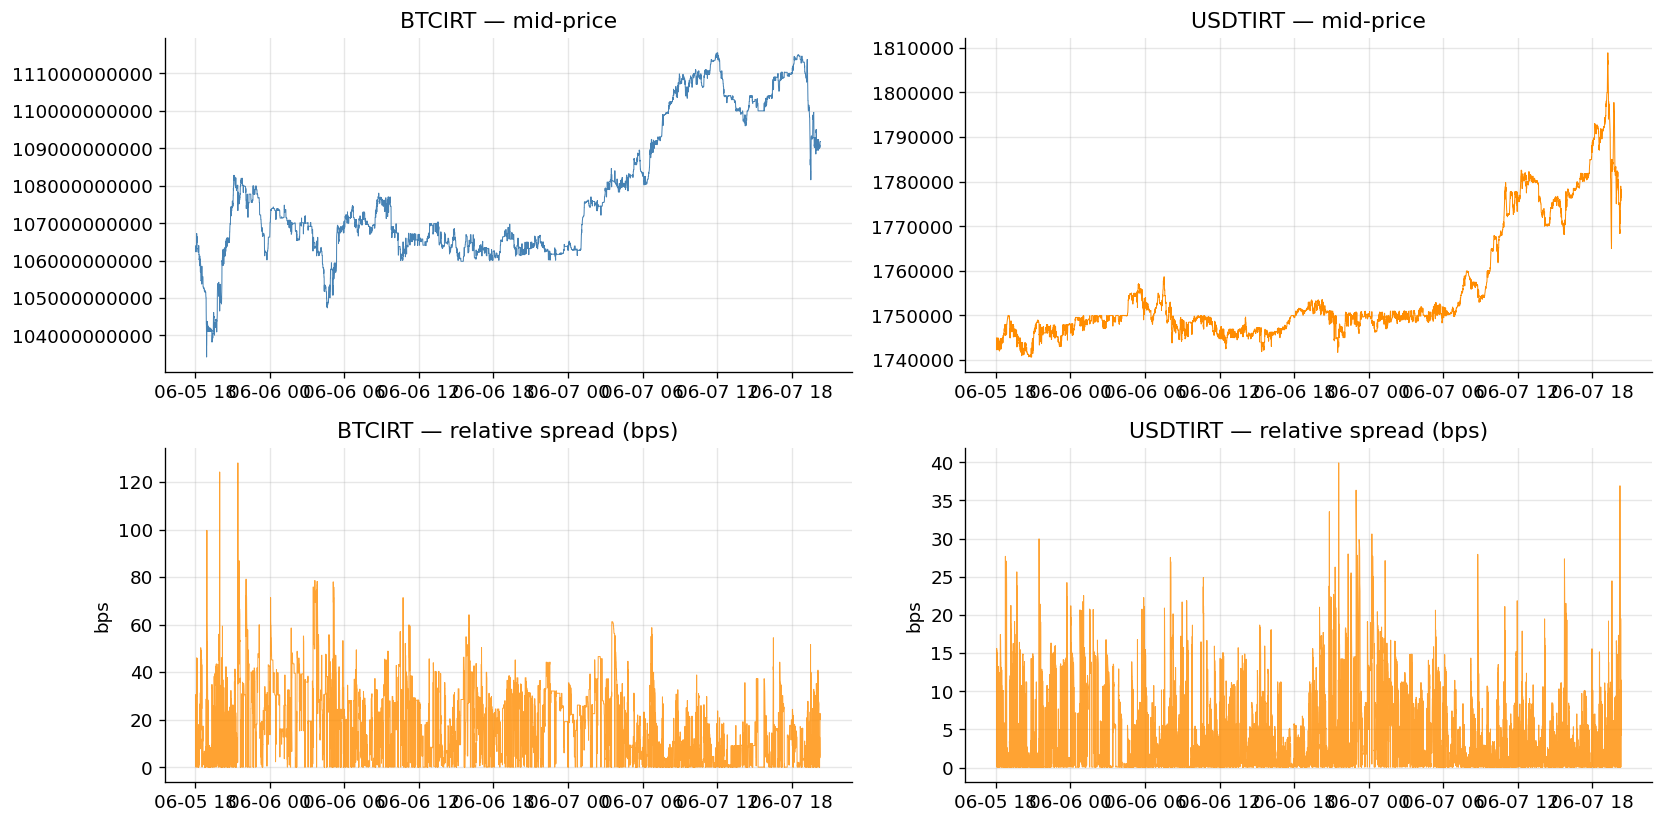

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for col, sym in enumerate(ASSETS):
    df = ob[sym]
    axes[0, col].plot(df["time"], df["mid_price"], lw=0.6, color=ASSET_COLORS[sym])
    axes[0, col].set_title(f"{sym} — mid-price")
    axes[0, col].yaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    axes[0, col].ticklabel_format(axis="y", style="plain")

    axes[1, col].plot(df["time"], df["rel_spread"] * 1e4, lw=0.6, color="darkorange", alpha=0.8)
    axes[1, col].set_title(f"{sym} — relative spread (bps)")
    axes[1, col].set_ylabel("bps")

plt.tight_layout()
plt.show()


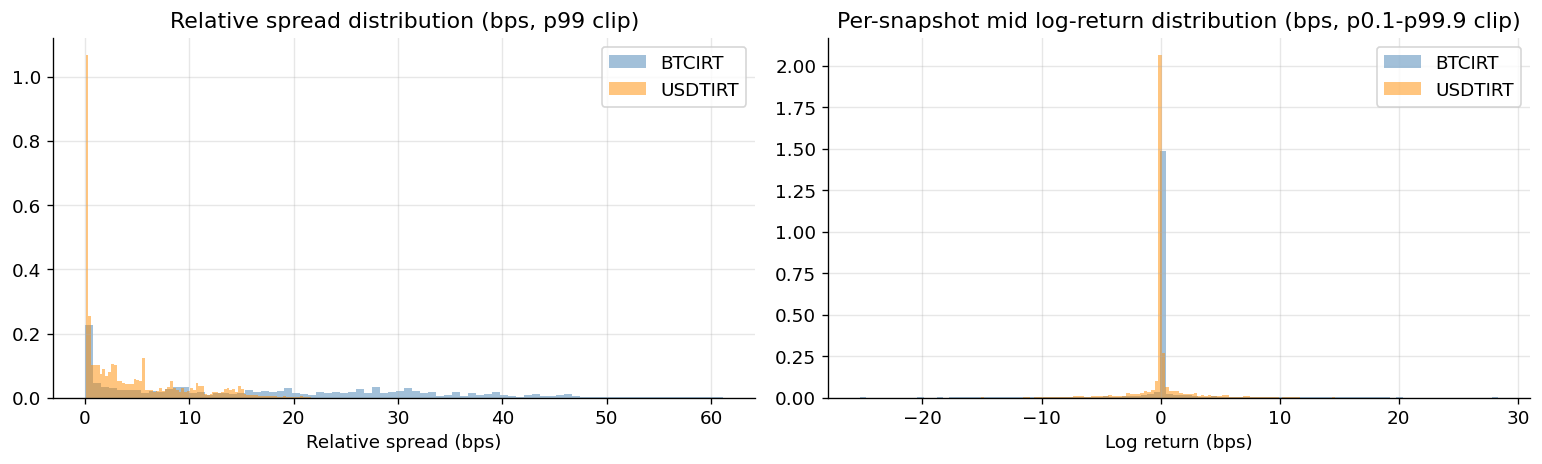

BTCIRT    median rel spread =  16.02 bps   per-snapshot log-return std =   4.00 bps
USDTIRT   median rel spread =   2.23 bps   per-snapshot log-return std =   2.35 bps


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# relative spread distribution
for sym in ASSETS:
    rs = ob[sym]["rel_spread"].dropna()
    rs = rs[rs > 0]
    p99 = rs.quantile(0.99)
    axes[0].hist(rs[rs <= p99] * 1e4, bins=80, alpha=0.5, label=sym, color=ASSET_COLORS[sym], density=True)
axes[0].set_title("Relative spread distribution (bps, p99 clip)")
axes[0].set_xlabel("Relative spread (bps)")
axes[0].legend()

# per-snapshot mid log-return distribution
for sym in ASSETS:
    lr = np.log(ob[sym]["mid_price"]).diff().dropna()
    lo, hi = lr.quantile(0.001), lr.quantile(0.999)
    axes[1].hist(lr.clip(lo, hi) * 1e4, bins=100, alpha=0.5, label=sym, color=ASSET_COLORS[sym], density=True)
axes[1].set_title("Per-snapshot mid log-return distribution (bps, p0.1-p99.9 clip)")
axes[1].set_xlabel("Log return (bps)")
axes[1].legend()

plt.tight_layout()
plt.show()

for sym in ASSETS:
    rs = ob[sym]["rel_spread"]
    rs = rs[rs > 0]
    lr = np.log(ob[sym]["mid_price"]).diff().dropna()
    print(f"{sym:8s}  median rel spread = {rs.median() * 1e4:6.2f} bps   "
          f"per-snapshot log-return std = {lr.std() * 1e4:6.2f} bps")


---
## 6. Order Imbalance

Order imbalance (OIB) at L1 captures directional pressure: +1 = all volume on the bid (buying pressure), -1 = all volume on the ask (selling pressure).

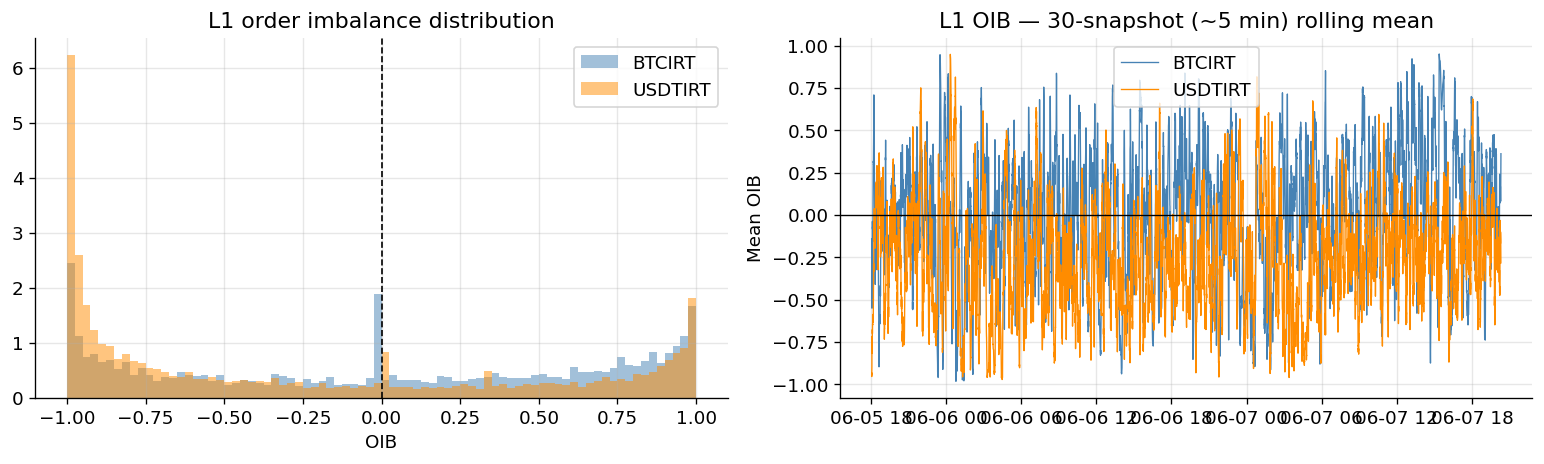

BTCIRT    OIB mean = +0.0164   std = 0.6802
USDTIRT   OIB mean = -0.2567   std = 0.7244


In [14]:
for sym in ASSETS:
    df = ob[sym]
    denom = df["bid_volume_1"] + df["ask_volume_1"]
    df["oib_l1"] = (df["bid_volume_1"] - df["ask_volume_1"]) / denom

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sym in ASSETS:
    oib = ob[sym]["oib_l1"].dropna()
    axes[0].hist(oib, bins=80, alpha=0.5, label=sym, color=ASSET_COLORS[sym], density=True)
axes[0].axvline(0, color="black", lw=1, ls="--")
axes[0].set_title("L1 order imbalance distribution")
axes[0].set_xlabel("OIB")
axes[0].legend()

for sym in ASSETS:
    df = ob[sym]
    axes[1].plot(df["time"], df["oib_l1"].rolling(30, min_periods=1).mean(), lw=0.8, label=sym, color=ASSET_COLORS[sym])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("L1 OIB — 30-snapshot (~5 min) rolling mean")
axes[1].set_ylabel("Mean OIB")
axes[1].legend()

plt.tight_layout()
plt.show()

for sym in ASSETS:
    oib = ob[sym]["oib_l1"].dropna()
    print(f"{sym:8s}  OIB mean = {oib.mean():+.4f}   std = {oib.std():.4f}")


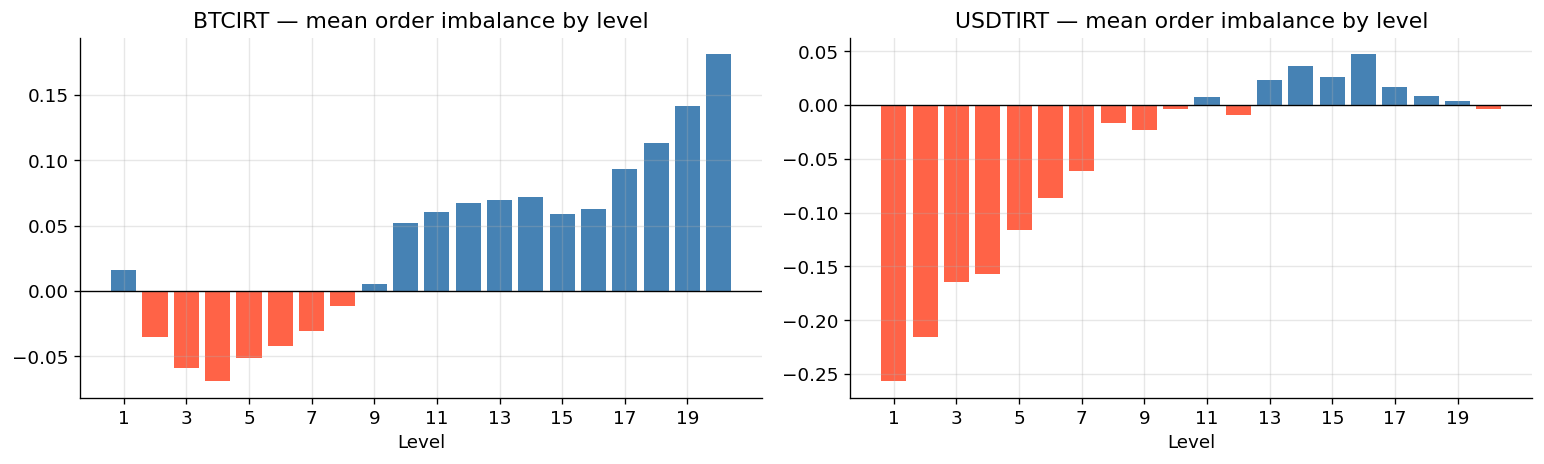

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sym in zip(axes, ASSETS):
    oib_by_level = []
    for i in range(1, N_LEVELS + 1):
        bv = ob[sym][f"bid_volume_{i}"]
        av = ob[sym][f"ask_volume_{i}"]
        oib_by_level.append(((bv - av) / (bv + av)).mean())
    colors = ["tomato" if v < 0 else "steelblue" for v in oib_by_level]
    ax.bar(LEVELS, oib_by_level, color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{sym} — mean order imbalance by level")
    ax.set_xlabel("Level")
    ax.set_xticks(LEVELS[::2])

plt.tight_layout()
plt.show()


---
## 7. Price Level Spacing (Tick Structure)

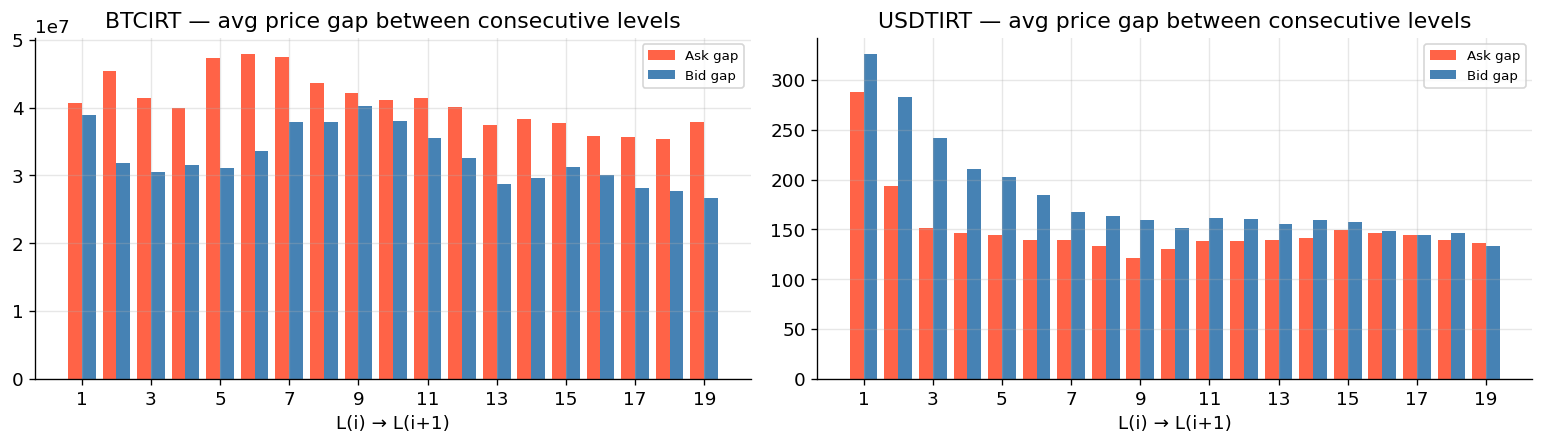

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sym in zip(axes, ASSETS):
    ask_arr = ob[sym][ASK_PRICE_COLS].values.astype(np.float64)
    bid_arr = ob[sym][BID_PRICE_COLS].values.astype(np.float64)
    ask_inc = np.diff(ask_arr, axis=1)  # L(i+1) - L(i), expected > 0
    bid_inc = np.diff(bid_arr, axis=1)  # expected < 0

    avg_ask_inc = np.nanmean(np.where(ask_inc > 0, ask_inc, np.nan), axis=0)
    avg_bid_inc = np.nanmean(np.where(bid_inc < 0, np.abs(bid_inc), np.nan), axis=0)

    x = np.arange(1, N_LEVELS)
    ax.bar(x - 0.2, avg_ask_inc, width=0.4, color="tomato", label="Ask gap")
    ax.bar(x + 0.2, avg_bid_inc, width=0.4, color="steelblue", label="Bid gap")
    ax.set_title(f"{sym} — avg price gap between consecutive levels")
    ax.set_xlabel("L(i) → L(i+1)")
    ax.set_xticks(x[::2])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 8. Trades Analysis

In [17]:
for sym in ASSETS:
    t = tr[sym]
    print(f"── {sym} trades ──")
    print(f"  n trades     : {len(t):,}")
    print(f"  range        : {t['trade_time'].min()}  →  {t['trade_time'].max()}")
    print(t["direction"].value_counts())
    print(t["volume"].describe())
    print()


── BTCIRT trades ──
  n trades     : 16,527
  range        : 2026-06-05 17:59:39.803000  →  2026-06-07 20:18:05.048000
direction
sell    9952
buy     6575
Name: count, dtype: int64
count    16527.000000
mean         0.001187
std          0.002981
min          0.000001
25%          0.000054
50%          0.000337
75%          0.000971
max          0.090277
Name: volume, dtype: float64

── USDTIRT trades ──
  n trades     : 60,492
  range        : 2026-06-05 18:02:28.356000  →  2026-06-07 20:18:40.797000
direction
buy     34161
sell    26331
Name: count, dtype: int64
count    60492.000000
mean       135.078897
std        425.909463
min          0.010000
25%          7.390000
50%         28.510000
75%        102.810000
max      17253.710000
Name: volume, dtype: float64



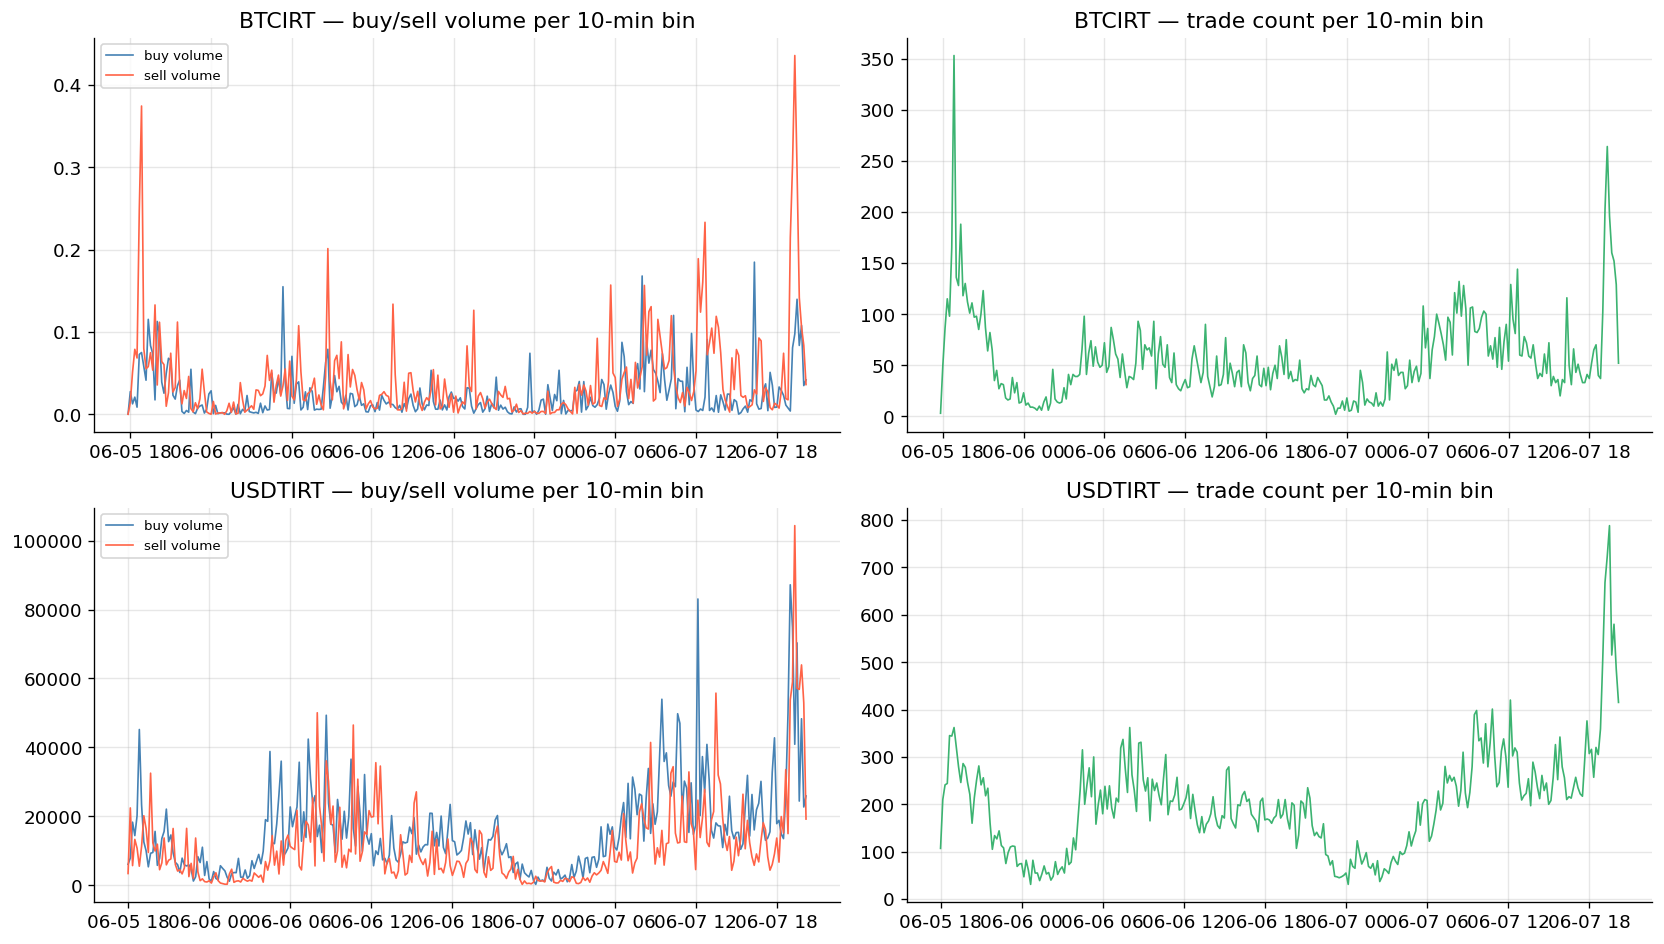

In [18]:
fig, axes = plt.subplots(len(ASSETS), 2, figsize=(14, 4 * len(ASSETS)))

for row, sym in enumerate(ASSETS):
    t = tr[sym]
    binned = t["trade_time"].dt.floor("10min")

    # buy/sell volume per 10-min bin
    vol_by_dir = t.groupby([binned, "direction"])["volume"].sum().unstack(fill_value=0)
    axes[row, 0].plot(vol_by_dir.index, vol_by_dir.get("buy", 0), color="steelblue", lw=1, label="buy volume")
    axes[row, 0].plot(vol_by_dir.index, vol_by_dir.get("sell", 0), color="tomato", lw=1, label="sell volume")
    axes[row, 0].set_title(f"{sym} — buy/sell volume per 10-min bin")
    axes[row, 0].legend(fontsize=8)

    # trade count per 10-min bin
    cnt = t.groupby(binned).size()
    axes[row, 1].plot(cnt.index, cnt.values, color="mediumseagreen", lw=1)
    axes[row, 1].set_title(f"{sym} — trade count per 10-min bin")

plt.tight_layout()
plt.show()


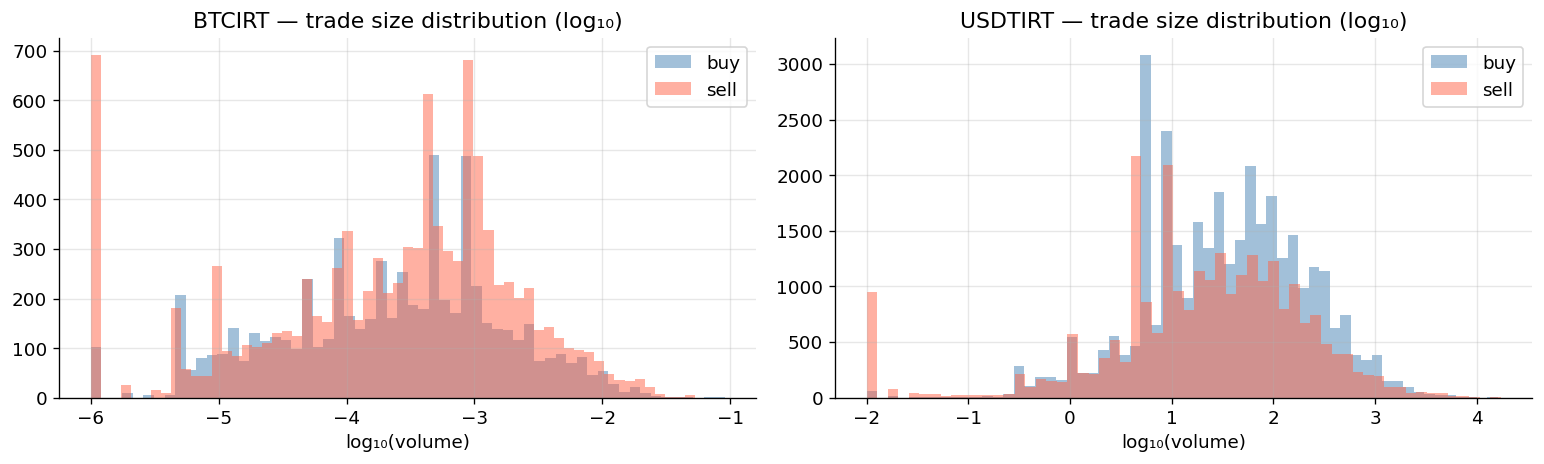

In [19]:
# trade size distribution by direction (log scale)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sym in zip(axes, ASSETS):
    t = tr[sym]
    for direction, color in [("buy", "steelblue"), ("sell", "tomato")]:
        v = t.loc[t["direction"] == direction, "volume"]
        v = v[v > 0]
        ax.hist(np.log10(v), bins=60, alpha=0.5, label=direction, color=color)
    ax.set_title(f"{sym} — trade size distribution (log₁₀)")
    ax.set_xlabel("log₁₀(volume)")
    ax.legend()

plt.tight_layout()
plt.show()


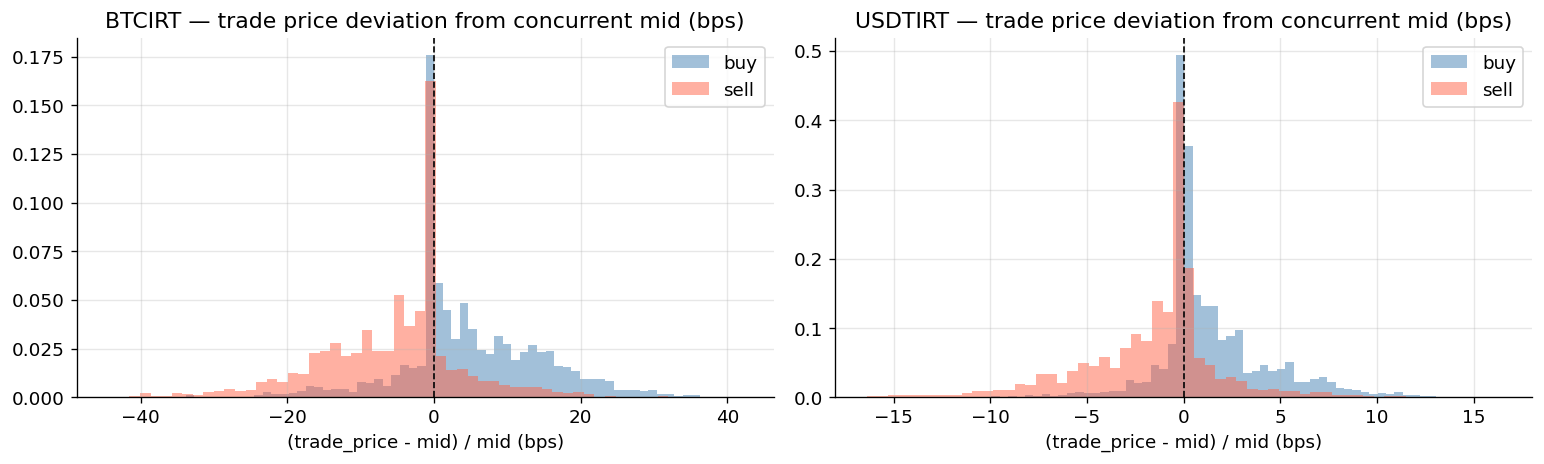

In [20]:
# link trades to the order book: trade price vs. prevailing mid-price at snapshot_time
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sym in zip(axes, ASSETS):
    t = tr[sym].merge(
        ob[sym][["time", "mid_price"]], left_on="snapshot_time", right_on="time", how="left"
    )
    t["price_dev_bps"] = (t["price"] - t["mid_price"]) / t["mid_price"] * 1e4
    for direction, color in [("buy", "steelblue"), ("sell", "tomato")]:
        d = t.loc[t["direction"] == direction, "price_dev_bps"].dropna()
        clip = d.abs().quantile(0.99)
        d = d[d.abs() <= clip]
        ax.hist(d, bins=60, alpha=0.5, label=direction, color=color, density=True)
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.set_title(f"{sym} — trade price deviation from concurrent mid (bps)")
    ax.set_xlabel("(trade_price - mid) / mid (bps)")
    ax.legend()

plt.tight_layout()
plt.show()


---
## 9. Forward Returns & Alpha Exploration

DeepLOB does **not** label on the raw point-to-point return `(mid[t+k] - mid[t]) / mid[t]`.
Following Zhang et al. (2019) / FI-2010, the target is a **smoothed** return built from two
moving averages of the mid-price over a horizon `k` (in snapshots, ~10s each):

- backward mean &nbsp;`m_-(t) = (1/k) . sum_{i=0}^{k-1} mid[t-i]` &nbsp; (current + previous k-1)
- forward mean &nbsp;&nbsp;`m_+(t) = (1/k) . sum_{i=1}^{k} mid[t+i]` &nbsp;&nbsp;&nbsp; (next k)
- label signal &nbsp;&nbsp;`l_t = (m_+(t) - m_-(t)) / m_-(t)`

Averaging both ends cancels single-snapshot quote bounce, so the flat class is far less
noisy than the raw return. We compute **both** signals to show the difference, then run all
alpha / horizon selection on the **smoothed (DeepLOB)** label.

Because the model pools **both** assets, we pick `alpha` three ways: **per-asset**,
**joint** (one `alpha` best for both), and **aggregated** (`alpha` on the pooled distribution).

In [21]:
# horizon k is in SNAPSHOTS (~10s each): k=6->1min, k=50->~8.3min, k=100->~16.7min
HORIZONS = {
    "10s": 1,
    "30s": 3,
    "1min": 6,
    "2min": 12,
    "5min": 30,
    "50sn": 50,
    "10min": 60,
    "100sn": 100,
}


def simple_return(mid, k):
    r = np.full(len(mid), np.nan)
    r[:-k] = (mid[k:] - mid[:-k]) / mid[:-k]
    return r


def deeplob_label(mid, k):
    # smoothed return: l_t = (m_+ - m_-)/m_-
    #   m_- = mean(mid[t-k+1 .. t]),  m_+ = mean(mid[t+1 .. t+k])
    s = pd.Series(mid)
    m_minus = s.rolling(k).mean()
    m_plus = s.rolling(k).mean().shift(-k)
    return ((m_plus - m_minus) / m_minus).values


simple_returns, smooth_returns = {}, {}
for sym in ASSETS:
    mid = ob[sym]["mid_price"].values
    simple_returns[sym] = {n: simple_return(mid, k) for n, k in HORIZONS.items()}
    smooth_returns[sym] = {n: deeplob_label(mid, k) for n, k in HORIZONS.items()}
for d in (simple_returns, smooth_returns):
    d["ALL"] = {n: np.concatenate([d[s][n] for s in ASSETS]) for n in HORIZONS}

# every alpha/horizon selection below runs on the smoothed DeepLOB label
LABEL = "smoothed (DeepLOB)"
fwd_returns = smooth_returns

print(f"{'asset':8s} {'horizon':7s} {'simple std':>12s} {'smoothed std':>14s}   (bps)")
for sym in ASSETS + ["ALL"]:
    for name in HORIZONS:
        rs = simple_returns[sym][name]
        rs = rs[~np.isnan(rs)]
        rm = smooth_returns[sym][name]
        rm = rm[~np.isnan(rm)]
        print(f"{sym:8s} {name:7s} {rs.std() * 1e4:12.2f} {rm.std() * 1e4:14.2f}")
    print()

asset    horizon   simple std   smoothed std   (bps)
BTCIRT   10s             4.00           4.00
BTCIRT   30s             6.48           5.31
BTCIRT   1min            8.89           7.16
BTCIRT   2min           12.41          10.02
BTCIRT   5min           19.39          15.54
BTCIRT   50sn           24.42          19.76
BTCIRT   10min          26.62          21.72
BTCIRT   100sn          34.92          29.07

USDTIRT  10s             2.35           2.35
USDTIRT  30s             3.65           2.95
USDTIRT  1min            5.00           4.02
USDTIRT  2min            7.05           5.72
USDTIRT  5min           10.89           8.56
USDTIRT  50sn           13.34          10.50
USDTIRT  10min          14.57          11.13
USDTIRT  100sn          16.93          12.35

ALL      10s             3.28           3.28
ALL      30s             5.26           4.29
ALL      1min            7.20           5.80
ALL      2min           10.08           8.15
ALL      5min           15.71          12.53


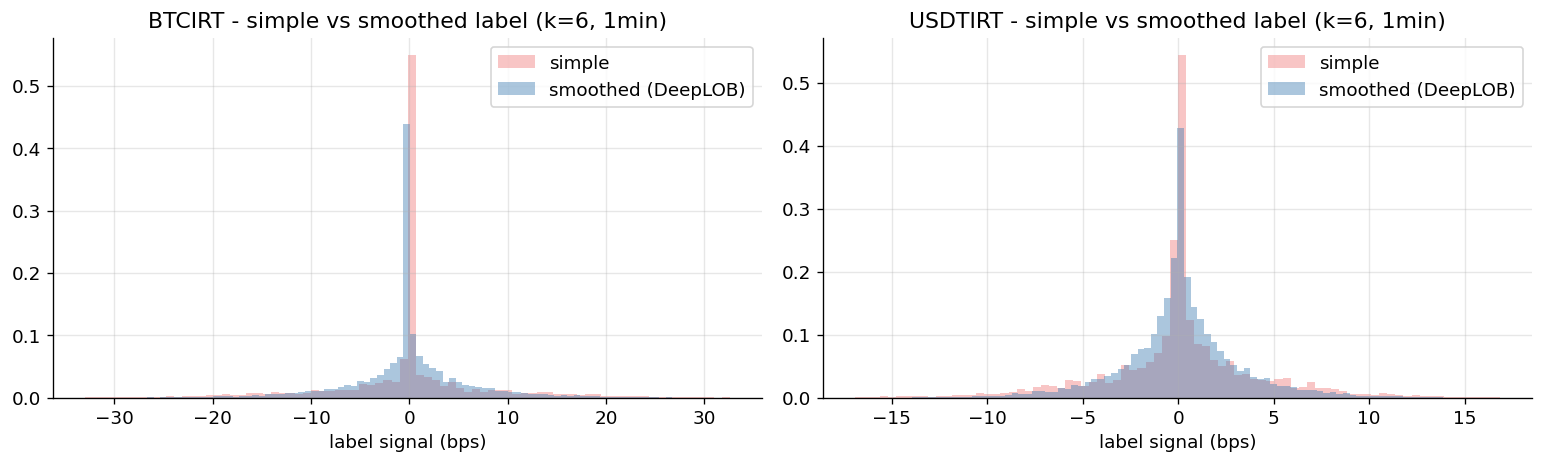

In [22]:
# how smoothing reshapes the label distribution (tighter core -> cleaner flat class)
CMP_HORIZON = "1min"  # change to inspect a different horizon

fig, axes = plt.subplots(1, len(ASSETS), figsize=(13, 4))
for ax, sym in zip(axes, ASSETS):
    for r, lab, color in [
        (simple_returns[sym][CMP_HORIZON], "simple", "lightcoral"),
        (smooth_returns[sym][CMP_HORIZON], "smoothed (DeepLOB)", "steelblue"),
    ]:
        r = r[~np.isnan(r)]
        clip = np.percentile(np.abs(r), 99)
        ax.hist(r[np.abs(r) <= clip] * 1e4, bins=80, alpha=0.45, density=True, label=lab, color=color)
    ax.set_title(f"{sym} - simple vs smoothed label (k={HORIZONS[CMP_HORIZON]}, {CMP_HORIZON})")
    ax.set_xlabel("label signal (bps)")
    ax.legend()
plt.tight_layout()
plt.show()

In [23]:
def alpha_scan(r, alphas_bps):
    # class composition (down/flat/up) and down/up imbalance for a grid of alpha (bps)
    r = r[~np.isnan(r)]
    rows = []
    for a_bps in alphas_bps:
        a = a_bps / 1e4
        n_down = int((r < -a).sum())
        n_up = int((r > a).sum())
        n_flat = len(r) - n_down - n_up
        total = len(r)
        rows.append(
            {
                "alpha_bps": a_bps,
                "pct_down": 100 * n_down / total,
                "pct_flat": 100 * n_flat / total,
                "pct_up": 100 * n_up / total,
                "imbalance": max(n_down, n_up) / (min(n_down, n_up) + 1),
            }
        )
    return pd.DataFrame(rows).set_index("alpha_bps")


FLAT_TARGET = 55.0  # desired % of samples in the flat (no-trade) class


def _score(scan, flat_target=FLAT_TARGET):
    # lower is better: penalise down/up asymmetry (x2) and deviation from flat target
    return (scan["imbalance"] - 1.0).abs() * 2 + (scan["pct_flat"] - flat_target).abs()


def recommend_alpha(r, alphas_bps, flat_target=FLAT_TARGET):
    scan = alpha_scan(r, alphas_bps)
    scan["combined_score"] = _score(scan, flat_target)
    best = scan["combined_score"].idxmin()
    return best, scan


# longer horizons need wider alpha → scan up to 150 bps
ALPHA_GRID_BPS = np.arange(1, 151, 1)

print(f"{'asset':8s} {'horizon':7s} {'best α':>7s} {'down %':>8s} {'flat %':>8s} {'up %':>8s} {'imbalance':>10s}")
recs = {}
for sym in ASSETS:
    recs[sym] = {}
    for hname in HORIZONS:
        best, scan = recommend_alpha(fwd_returns[sym][hname], ALPHA_GRID_BPS)
        recs[sym][hname] = (best, scan)
        row = scan.loc[best]
        print(
            f"{sym:8s} {hname:7s} {best:5d}bp {row['pct_down']:8.1f} {row['pct_flat']:8.1f} "
            f"{row['pct_up']:8.1f} {row['imbalance']:10.2f}"
        )
    print()


asset    horizon  best α   down %   flat %     up %  imbalance
BTCIRT   10s         1bp      8.1     83.6      8.3       1.03
BTCIRT   30s         1bp     20.6     57.7     21.7       1.05
BTCIRT   1min        2bp     23.6     51.8     24.6       1.04
BTCIRT   2min        4bp     22.7     53.7     23.6       1.04
BTCIRT   5min        8bp     20.6     56.7     22.7       1.10
BTCIRT   50sn       10bp     21.4     54.0     24.5       1.15
BTCIRT   10min      11bp     21.6     53.3     25.1       1.16
BTCIRT   100sn      16bp     19.6     55.6     24.8       1.26

USDTIRT  10s         1bp     10.9     77.8     11.4       1.05
USDTIRT  30s         1bp     21.6     55.2     23.1       1.07
USDTIRT  1min        2bp     18.1     62.3     19.6       1.09
USDTIRT  2min        2bp     23.6     50.2     26.2       1.11
USDTIRT  5min        4bp     18.2     60.0     21.8       1.20
USDTIRT  50sn        4bp     21.6     51.6     26.9       1.25
USDTIRT  10min       5bp     18.9     56.7     24.4   

### Joint vs. aggregated alpha

**Joint α** = the single threshold minimising the *summed* score of both assets — the best one-size-fits-both choice for a pooled model. **Aggregated α** = best threshold on the pooled return distribution. The table reports, for every horizon, each asset's own optimum plus the resulting per-asset class balance under the joint α.

In [24]:
def joint_best_alpha(horizon, alphas_bps, flat_target=FLAT_TARGET):
    # single alpha minimising the SUM of both assets' scores (good for BOTH)
    scans = {s: alpha_scan(fwd_returns[s][horizon], alphas_bps) for s in ASSETS}
    total = None
    for s in ASSETS:
        sc = _score(scans[s], flat_target)
        total = sc if total is None else total + sc
    return int(total.idxmin()), scans, total


rows = []
for hname in HORIZONS:
    jbest, jscans, _ = joint_best_alpha(hname, ALPHA_GRID_BPS)
    abest, ascan = recommend_alpha(fwd_returns["ALL"][hname], ALPHA_GRID_BPS)
    arow = ascan.loc[abest]
    rows.append(
        {
            "horizon": hname,
            "k": HORIZONS[hname],
            "BTC_α": recs["BTCIRT"][hname][0],
            "USDT_α": recs["USDTIRT"][hname][0],
            "joint_α": jbest,
            "joint_BTC_flat%": jscans["BTCIRT"].loc[jbest, "pct_flat"],
            "joint_BTC_imb": jscans["BTCIRT"].loc[jbest, "imbalance"],
            "joint_USDT_flat%": jscans["USDTIRT"].loc[jbest, "pct_flat"],
            "joint_USDT_imb": jscans["USDTIRT"].loc[jbest, "imbalance"],
            "agg_α": abest,
            "agg_flat%": arow["pct_flat"],
            "agg_imb": arow["imbalance"],
        }
    )

comp = pd.DataFrame(rows).set_index("horizon")
print("Per-asset / joint / aggregated alpha by horizon (α in bps):")
comp.round(2)


Per-asset / joint / aggregated alpha by horizon (α in bps):


,k,BTC_α,USDT_α,joint_α,joint_BTC_flat%,joint_BTC_imb,joint_USDT_flat%,joint_USDT_imb,agg_α,agg_flat%,agg_imb
horizon,,,,,,,,,,,
10s,1,1,1,1,83.64,1.03,77.77,1.05,1,80.69,1.04
30s,3,1,1,1,57.67,1.05,55.25,1.07,1,56.45,1.06
1min,6,2,2,2,51.76,1.04,62.31,1.09,2,57.05,1.06
2min,12,4,2,3,46.09,1.03,63.82,1.18,3,54.99,1.09
5min,30,8,4,4,35.71,1.03,60.01,1.20,5,54.75,1.09
50sn,50,10,4,10,54.03,1.15,82.13,1.53,7,56.26,1.19
10min,60,11,5,11,53.26,1.16,81.93,1.60,7,52.75,1.19
100sn,100,16,6,6,24.30,1.15,56.62,1.36,10,56.09,1.33


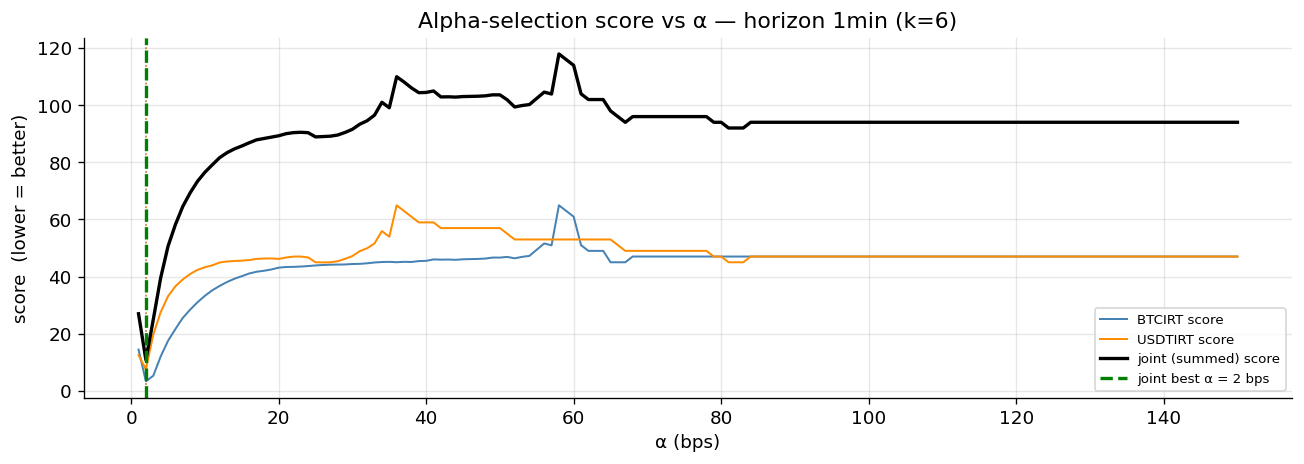

In [38]:
# Score-vs-alpha curves: where the joint optimum sits relative to each asset's optimum
SEL_HORIZON = "1min"  # ← change to inspect a different horizon
jbest, jscans, total = joint_best_alpha(SEL_HORIZON, ALPHA_GRID_BPS)

fig, ax = plt.subplots(figsize=(11, 4))
for s, color in zip(ASSETS, ["steelblue", "darkorange"]):
    ax.plot(jscans[s].index, _score(jscans[s]).values, color=color, lw=1.2, label=f"{s} score")
    ax.axvline(recs[s][SEL_HORIZON][0], color=color, ls=":", lw=1.0, alpha=0.8)
ax.plot(total.index, total.values, color="black", lw=2.0, label="joint (summed) score")
ax.axvline(jbest, color="green", lw=2.0, ls="--", label=f"joint best α = {jbest} bps")
ax.set_xlabel("α (bps)")
ax.set_ylabel("score  (lower = better)")
ax.set_title(f"Alpha-selection score vs α — horizon {SEL_HORIZON} (k={HORIZONS[SEL_HORIZON]})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


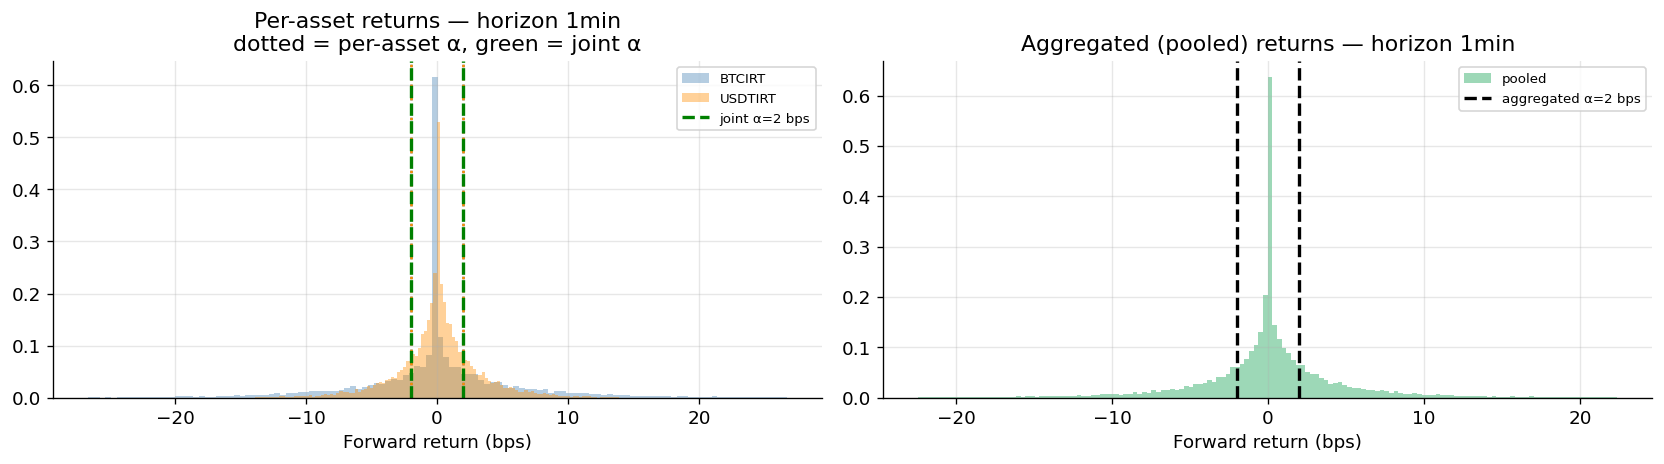

In [36]:
# Compare per-asset, joint, and aggregated alphas on the return distributions
SHOW_HORIZON = "1min"  # ← change to inspect a different horizon
jbest, jscans, _ = joint_best_alpha(SHOW_HORIZON, ALPHA_GRID_BPS)
abest, _ = recommend_alpha(fwd_returns["ALL"][SHOW_HORIZON], ALPHA_GRID_BPS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: per-asset distributions; dotted = each asset's own α, green = joint α
for sym, color in zip(ASSETS, ["steelblue", "darkorange"]):
    r = fwd_returns[sym][SHOW_HORIZON]
    r = r[~np.isnan(r)]
    clip = np.percentile(np.abs(r), 99)
    axes[0].hist(r[np.abs(r) <= clip] * 1e4, bins=120, density=True, alpha=0.4, color=color, label=sym)
    a = recs[sym][SHOW_HORIZON][0]
    axes[0].axvline(a, color=color, ls=":", lw=1.5)
    axes[0].axvline(-a, color=color, ls=":", lw=1.5)
axes[0].axvline(jbest, color="green", lw=2.0, ls="--", label=f"joint α={jbest} bps")
axes[0].axvline(-jbest, color="green", lw=2.0, ls="--")
axes[0].set_title(f"Per-asset returns — horizon {SHOW_HORIZON}\ndotted = per-asset α, green = joint α")
axes[0].set_xlabel("Forward return (bps)")
axes[0].legend(fontsize=8)

# right: aggregated (pooled) distribution with the aggregated α
r = fwd_returns["ALL"][SHOW_HORIZON]
r = r[~np.isnan(r)]
clip = np.percentile(np.abs(r), 99)
axes[1].hist(r[np.abs(r) <= clip] * 1e4, bins=150, density=True, color="mediumseagreen", alpha=0.5, label="pooled")
axes[1].axvline(abest, color="black", lw=2.0, ls="--", label=f"aggregated α={abest} bps")
axes[1].axvline(-abest, color="black", lw=2.0, ls="--")
axes[1].set_title(f"Aggregated (pooled) returns — horizon {SHOW_HORIZON}")
axes[1].set_xlabel("Forward return (bps)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### Takeaways for choosing the label

- **Use the smoothed (DeepLOB) label, not the simple return.** Averaging the `k` snapshots on
  each side of `t` cancels single-quote bounce: it cuts the label std by **~20-25%** at every
  horizon past 10s (e.g. BTCIRT 1min 8.9 -> 7.2 bps) and pulls the down/up imbalance toward 1.0,
  so the flat class is cleaner and the same `alpha` buys a more balanced split.
- **Per-asset optima still diverge.** BTCIRT needs a ~2-2.5x wider `alpha` than the USDTIRT
  stablecoin pair (its return vol is ~2x higher), so a single global threshold can't be optimal
  for both - scale `alpha` per asset if you can.
- **Horizon sweet spot is k=6-12 (1-2 min).** By the *joint* score (one `alpha` best for both
  assets) the cleanest balance is at **1min** (`alpha`~2 bps), with near-perfect class symmetry
  (imbalance ~1.04 BTC, ~1.09 USDT); by the *aggregated* (pooled) score the best is **2min**
  (`alpha`~3 bps, imbalance 1.09). Both keep flat near the ~55% target. Shorter (30s) forces
  `alpha`=1 bp at the tick-resolution limit; longer (>=5min) lets USDTIRT's class balance and the
  BTC/USDT flat-gap blow out (USDT imbalance 1.20 -> 1.36 by 100sn).
- **Recommendation.** Train DeepLOB on the **smoothed label at k=12 (2 min)**: per-asset
  **BTC `alpha`~=4 bps / USDT `alpha`~=2 bps**, or a single **aggregated `alpha`~=3 bps** if one global
  cut is required. k=6 (1 min) is an equally defensible faster-signal alternative.

---
## 10. Cross-Asset Summary

In [27]:
summary_rows = []
for sym in ASSETS:
    df, t = ob[sym], tr[sym]
    rs = df["rel_spread"]
    rs = rs[rs > 0]
    summary_rows.append(
        {
            "asset": sym,
            "n_snapshots": len(df),
            "n_trades": len(t),
            "median_rel_spread_bps": rs.median() * 1e4,
            "std_1min_ret_bps": np.nanstd(fwd_returns[sym]["1min"]) * 1e4,
            "std_5min_ret_bps": np.nanstd(fwd_returns[sym]["5min"]) * 1e4,
            "mean_oib_l1": df["oib_l1"].mean(),
            "buy_pct": (t["direction"] == "buy").mean() * 100,
        }
    )

pd.DataFrame(summary_rows).set_index("asset")


,n_snapshots,n_trades,median_rel_spread_bps,std_1min_ret_bps,std_5min_ret_bps,mean_oib_l1,buy_pct
asset,,,,,,,
BTCIRT,17348,16527,16.021408,7.160308,15.541183,0.016419,39.783385
USDTIRT,17483,60492,2.230235,4.020152,8.557451,-0.256736,56.471930
